# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import pandas as pd


## Creamos la sesión de spark

In [2]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [3]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [4]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [5]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [6]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 1

In [7]:
resultado_estatico = spark.read.parquet("resultados/")
resultado_estatico.printSchema()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)



In [8]:
total_filas = resultado_estatico.count()
print(f"El DataFrame contiene {total_filas} filas.")

El DataFrame contiene 1784 filas.


In [9]:
sensores_distintos = resultado_estatico.select("sensor_id").distinct().count()
print(f"Hay {sensores_distintos} sensores distintos.")

Hay 4 sensores distintos.


### Ejercicio 2

In [10]:
nueva_columna = resultado_estatico.withColumn(
    "temperatura_humedad",
    col("avg_temp") / col("avg_humidity")
)
nueva_columna.printSchema()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)
 |-- temperatura_humedad: double (nullable = true)



In [11]:
estadisticas = nueva_columna.agg(
    max("temperatura_humedad").alias("maximo"),
    min("temperatura_humedad").alias("minimo"),
    mean("temperatura_humedad").alias("media")
)

estadisticas.show()

+------------------+------------------+------------------+
|            maximo|            minimo|             media|
+------------------+------------------+------------------+
|2.5772155054219117|0.3887981489043147|1.0215281534437723|
+------------------+------------------+------------------+



### Ejercicio 3

In [12]:
df_filtrado = nueva_columna.filter((col("avg_temp") >= 50) & (col("avg_humidity") >= 20) & (col("sensor_id") == "S1"))
total_filas2 = df_filtrado.count()
print(f"El DataFrame contiene {total_filas2} filas.")

El DataFrame contiene 344 filas.


### Ejercicio 4

In [13]:
agrupacion_sensor_id = (
    nueva_columna.groupBy("sensor_id").agg(
        
            avg("avg_value").alias("medida_media"),
            max("avg_temp").alias("temperatura_maxima"),
            count("window").alias("numero_ventanas")
)
)
agrupacion_sensor_id.show(4)

+---------+------------------+------------------+---------------+
|sensor_id|      medida_media|temperatura_maxima|numero_ventanas|
+---------+------------------+------------------+---------------+
|       S4| 29.57025468605261|            81.465|            446|
|       S3|30.078562276599826| 80.64500000000001|            446|
|       S2|30.145907007012664| 81.30499999999999|            446|
|       S1|29.928272806540754|            82.912|            446|
+---------+------------------+------------------+---------------+



In [14]:
#¿Qué sensor tiene la mayor media en la variable analizada?
mayor_media_row = agrupacion_sensor_id.orderBy(col("medida_media").desc()).first()
print(f"1. El sensor con la mayor media es: {mayor_media_row['sensor_id']} (Media: {mayor_media_row['medida_media']:.2f})")

1. El sensor con la mayor media es: S2 (Media: 30.15)


In [15]:
#¿Qué sensor presenta la temperatura máxima?
max_temp_row = agrupacion_sensor_id.orderBy(col("temperatura_maxima").desc()).first()
print(f"2. El sensor con la temperatura máxima es: {max_temp_row['sensor_id']} (Máx: {max_temp_row['temperatura_maxima']:.2f} ºC)")

2. El sensor con la temperatura máxima es: S1 (Máx: 82.91 ºC)


In [16]:
#¿Cuántos grupos o ventanas existen por sensor?
print("3. Cantidad de ventanas procesadas por cada sensor:")
agrupacion_sensor_id.select("sensor_id", "numero_ventanas").show()

3. Cantidad de ventanas procesadas por cada sensor:
+---------+---------------+
|sensor_id|numero_ventanas|
+---------+---------------+
|       S4|            446|
|       S3|            446|
|       S2|            446|
|       S1|            446|
+---------+---------------+



### Ejercicio 5

In [17]:
window_max_value = Window.partitionBy("sensor_id").orderBy(col("avg_value").desc())
df_max_por_sensor = (
    nueva_columna
    .withColumn("rank", row_number().over(window_max_value))
    .filter(col("rank") == 1)
    .select("sensor_id", "avg_value")
)
print("=== El mayor valor medio para cada sensor ===")
df_max_por_sensor.show()

=== El mayor valor medio para cada sensor ===
+---------+------------------+
|sensor_id|         avg_value|
+---------+------------------+
|       S1|46.818000000000005|
|       S2| 45.81999999999999|
|       S3|             41.71|
|       S4|40.793749999999996|
+---------+------------------+



### Ejercicio 6

In [18]:
# Crea un dataframe auxiliar
aux_schema = StructType([
    StructField("sensor_id", StringType(), True),
    StructField("categoria", StringType(), True),
    StructField("ubicacion", StringType(), True),
    StructField("tipo_sensor", StringType(), True)
])

datos_sensores = [
    ("S1", "Industrial", "Almacén A", "Temperatura/Humedad"),
    ("S2", "Ambiental", "Zona Exterior", "Climatológico"),
    ("S3", "Seguridad", "Entrada Principal", "Térmico"),
    ("S4", "Industrial", "Planta de Producción", "Alta Precisión")
]

df_auxiliar = spark.createDataFrame(datos_sensores, schema=aux_schema)

In [19]:
#hacemos el join

df_unido = agrupacion_sensor_id.join(df_auxiliar, on="sensor_id", how="left")
df_unido.show(5)

+---------+------------------+------------------+---------------+----------+--------------------+-------------------+
|sensor_id|      medida_media|temperatura_maxima|numero_ventanas| categoria|           ubicacion|        tipo_sensor|
+---------+------------------+------------------+---------------+----------+--------------------+-------------------+
|       S4| 29.57025468605261|            81.465|            446|Industrial|Planta de Producción|     Alta Precisión|
|       S3|30.078562276599826| 80.64500000000001|            446| Seguridad|   Entrada Principal|            Térmico|
|       S2|30.145907007012664| 81.30499999999999|            446| Ambiental|       Zona Exterior|      Climatológico|
|       S1|29.928272806540754|            82.912|            446|Industrial|           Almacén A|Temperatura/Humedad|
+---------+------------------+------------------+---------------+----------+--------------------+-------------------+



### Ejercicio 7

In [20]:
df_con_tiempo = nueva_columna.withColumn(
    "unidad_temporal", 
    date_trunc("hour", col("window.start"))
)

analisis_temporal = (
    df_con_tiempo.groupBy("unidad_temporal")
    .agg(
        count("*").alias("total_ventanas"),
        avg("avg_humidity").alias("humedad_media")
    )
    .orderBy("unidad_temporal")
)

print("=== Análisis por Unidad Temporal (Hora) ===")
analisis_temporal.show()

=== Análisis por Unidad Temporal (Hora) ===
+-------------------+--------------+------------------+
|    unidad_temporal|total_ventanas|     humedad_media|
+-------------------+--------------+------------------+
|2026-02-04 11:00:00|           116| 55.39268876262627|
|2026-02-04 12:00:00|           480| 55.03774519774207|
|2026-02-04 13:00:00|           480|55.032838543285415|
|2026-02-04 14:00:00|           480|55.374549259189884|
|2026-02-04 15:00:00|           228|55.832635978178736|
+-------------------+--------------+------------------+



### Ejercicio 8

In [21]:
df_particionado = nueva_columna.repartition(20,"sensor_id")
df_con_particion = df_particionado.withColumn("partition_id", spark_partition_id())

distribucion = (
    df_con_particion.groupBy("partition_id")
    .agg(count("*").alias("num_registros"))
    .orderBy("partition_id")
)

print("=== Distribución de registros por partición ===")
distribucion.show()

=== Distribución de registros por partición ===
+------------+-------------+
|partition_id|num_registros|
+------------+-------------+
|           3|          446|
|           8|          446|
|           9|          446|
|          17|          446|
+------------+-------------+



### Ejercicio 9

In [22]:
media_temp_global = nueva_columna.select(avg("avg_temp")).collect()[0][0]
umbral_anomalia = media_temp_global * 1.20

df_anomalias = nueva_columna.filter(col("avg_temp") > umbral_anomalia)

In [23]:
#¿Cuántos registros son anómalos?
total_anomalias = df_anomalias.count()
print(f"Total de registros anómalos encontrados: {total_anomalias}")

Total de registros anómalos encontrados: 145


In [24]:
#¿Qué sensor tiene más anomalías?
if total_anomalias > 0:
    sensor_mas_anomalo = (
        df_anomalias.groupBy("sensor_id")
        .count()
        .orderBy(col("count").desc())
        .first()
    )
    print(f"El sensor con más anomalías es: {sensor_mas_anomalo['sensor_id']} con {sensor_mas_anomalo['count']} registros.")
else:
    print("No se detectaron anomalías")

El sensor con más anomalías es: S3 con 40 registros.


### Ejercicio 10

In [25]:
df_puntuacion = nueva_columna.withColumn(
    "puntuacion_final",
    (col("avg_value") * 0.5) + 
    (col("avg_temp") * 0.3) + 
    (col("avg_humidity") * 0.2)
)

ganador = df_puntuacion.orderBy(col("puntuacion_final").desc()).first()

In [26]:
# ¿Qué sensor obtiene la puntuación más alta?

print("=== Resultado ===")
print(f"El sensor con la puntuación más alta es: {ganador['sensor_id']}")
print(f"Valor de la puntuación: {ganador['puntuacion_final']:.2f}")

=== Resultado ===
El sensor con la puntuación más alta es: S3
Valor de la puntuación: 56.47


### Ejercicio 11

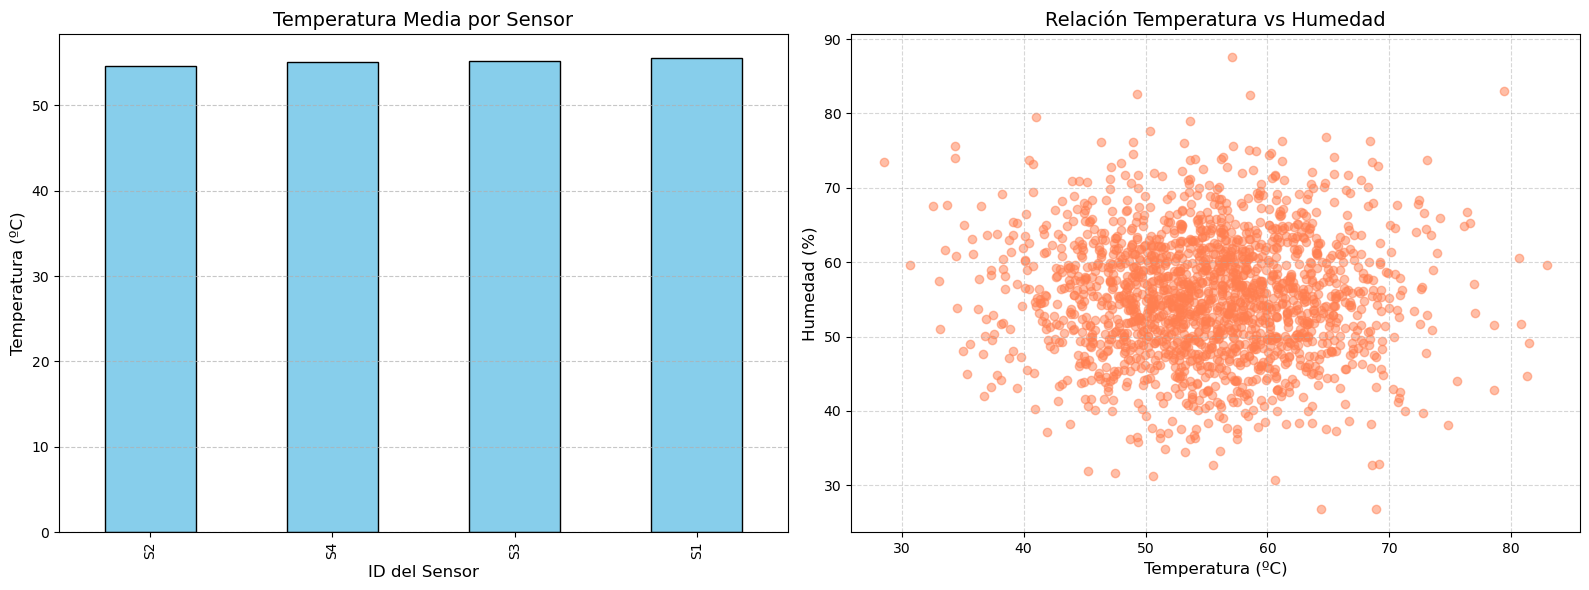

In [27]:
p_df = nueva_columna.toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Temperatura Media por Sensor (Gráfico de barras) ---

temp_por_sensor = p_df.groupby("sensor_id")["avg_temp"].mean().sort_values()

temp_por_sensor.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title("Temperatura Media por Sensor", fontsize=14)
ax1.set_xlabel("ID del Sensor", fontsize=12)
ax1.set_ylabel("Temperatura (ºC)", fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- GRÁFICO 2: Relación Temperatura vs Humedad (Gráfico de dispersión) ---

ax2.scatter(p_df["avg_temp"], p_df["avg_humidity"], alpha=0.5, color='coral')
ax2.set_title("Relación Temperatura vs Humedad", fontsize=14)
ax2.set_xlabel("Temperatura (ºC)", fontsize=12)
ax2.set_ylabel("Humedad (%)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()